<a href="https://colab.research.google.com/github/srabani-khuntia/LLM_Using_Python/blob/main/30th_May.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

input_text = '''
After a long day at work, Sarah decided to relax by taking her dog for a walk in the park. As they strolled along the tree-lined paths, Sarah's dog, Max, eagerly sniffed around, chasing after squirrels and birds. Sarah smiled as she watched Max enjoy himself, feeling grrateful for the companionship and joy that her furry friend brought into her life. '''

tokens = tokenizer(input_text, return_tensors = "pt")

with torch.no_grad():
    outputs = model(**tokens) #generating token embeddings

    last_hidden_states = outputs.last_hidden_state #extracts a token from the last...

    print("Token embeddings: ")
    for token, embedding in zip(tokens["input_ids"][0], last_hidden_states[0]):
        word = tokenizer.decode(int(token))
        print(f"{word}: {embedding}")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
         5.6789e-01,  1.8135e-02, -1.1757e+00, -6.6974e-01, -2.4457e-01,
        -1.9343e-01,  2.9201e-01, -6.3058e-02,  2.9797e-02, -5.6329e-01,
         4.9115e-01, -9.5511e-01, -3.0264e-01, -3.4223e-01,  1.4643e+00,
         1.1788e+00,  1.1304e-01, -1.2322e-01, -9.0151e-01,  3.2583e-01,
        -1.5231e-01, -2.2910e-01, -4.2360e-01,  5.9660e-01, -3.7920e-01,
        -1.4106e-01, -1.6316e-01, -7.5159e-01, -5.8403e-01, -3.0311e-01,
         6.3646e-02, -5.1619e-02,  8.1914e-01,  1.1296e-02, -5.3195e-01,
        -1.4774e+00, -1.0694e+00,  4.2427e-01, -3.3631e-01,  2.4570e-01,
         2.2242e-01,  6.9023e-01,  1.2324e+00,  6.6229e-01, -3.6041e-01,
        -4.8176e-01, -4.6492e-01,  1.8200e-01, -7.0598e-02,  3.5032e-02,
        -5.6326e-01,  1.5405e-01,  7.2450e-01,  7.2354e-02,  9.0458e-01,
        -5.3245e-02,  2.8242e-01, -1.4321e+00,  1.3209e-01,  1.1033e+00,
        -5.9884e-01,  8.5661e-01, -6.3905e-01,  5.2810e-01,  6.2141e-01,


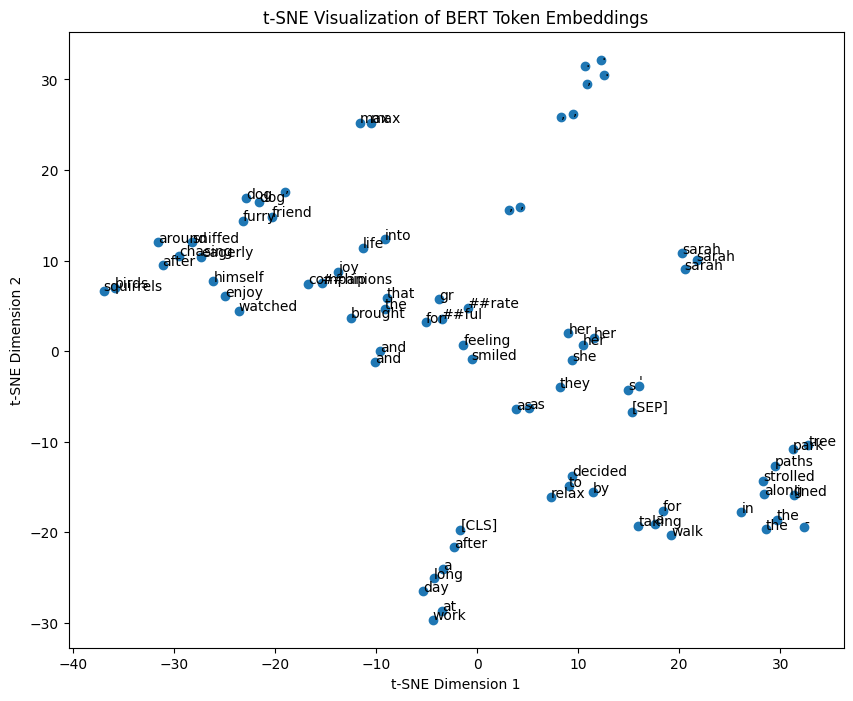

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components = 2, perplexity = 5, random_state = 42)
embeddings_tsne = tsne.fit_transform(last_hidden_states[0])

plt.figure(figsize = (10, 8))
plt.scatter(embeddings_tsne[:, 0],
            embeddings_tsne[:, 1], marker = 'o')

for i, word in enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])):
  plt.annotate(word, xy = (embeddings_tsne[i, 0], embeddings_tsne[i, 1]),
               fontsize = 10)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of BERT Token Embeddings")
plt.show()